# **Part III: Industrial Control System (ICS) Anomaly Detection**

## **TON_IoT - Modbus Dataset**

In the previous part, we focused on the **Space Segment** (satellite telemetry). Now, we move to the **Ground Segment**. A satellite ground station relies on critical physical infrastructure: antenna motors, power supply units, and cooling systems. These Operational Technology (OT) devices are often controlled via industrial protocols like **Modbus**.

For this part of the project, we selected the **TON_IoT** dataset collection, specifically the **Modbus** subset.

### **Dataset Selection & Description**
Unlike general IT network datasets (like CIC-IDS), this dataset captures communication between Master and Slave nodes in an industrial control system. It simulates realistic attacks against cyber-physical systems.

We use the pre-processed `Train_Test_IoT_Modbus.csv` file which provides labeled samples ready for machine learning.

**Features (Input):**
* The dataset contains specific Modbus function codes used to read or write data to the programmable logic controllers (PLCs):
    * `FC1_Read_Input_Register`
    * `FC2_Read_Discrete_Value`
    * `FC3_Read_Holding_Register`
    * `FC4_Read_Coil`
* It also contains timestamps (`date`, `time`) which we will remove during preprocessing to prevent the model from learning temporal biases.

**Target (Output):**
* `label`: Binary classification (0 = Normal, 1 = Attack).
* `type`: The specific attack category (e.g., *injection*, *xss*, *scanning*). In this notebook, we focus on binary detection of **Injection attacks**.

### **Objective & Model**
The goal is to build a "Ground Facility Specialist" model capable of flagging malicious commands sent to the ground station equipment.

Given the tabular nature of the data and the non-linear relationships in sensor readings, we will use **XGBoost (Extreme Gradient Boosting)**. This algorithm is widely considered state-of-the-art for this type of structured data, offering high performance and execution speed.

In this notebook we will:
1. Load and clean the Modbus dataset.
2. Remove metadata columns (date, time, specific attack type).
3. Train an **XGBoost Classifier** on the training set.
4. Evaluate its performance (Recall, Precision, F1-score) to validate its integration into the global "Flight Director" architecture.

In [1]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# ML Utils
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 2. DATA LOADING
# ==========================================
DATA_FILE = "Train_Test_IoT_Modbus.csv"

# Safety check before loading
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"Critical: File '{DATA_FILE}' missing in current directory.")

print(f"Loading {DATA_FILE}...")
df = pd.read_csv(DATA_FILE)

# Quick look
print(f"Dataset shape: {df.shape}")
df.head()

Loading Train_Test_IoT_Modbus.csv...
Dataset shape: (31106, 8)


,date,time,FC1_Read_Input_Register,FC2_Read_Discrete_Value,FC3_Read_Holding_Register,FC4_Read_Coil,label,type
0,25-Apr-19,09:14:00,49389,52921,25770,13625,1,injection
1,25-Apr-19,09:14:00,49389,52921,25770,13625,1,injection
2,25-Apr-19,09:14:01,49389,52921,25770,13625,1,injection
3,25-Apr-19,09:14:02,49389,52921,25770,13625,1,injection
4,25-Apr-19,09:14:04,40665,44748,21098,35371,1,injection


## 3. Data Preprocessing

To create a robust model, we perform the following steps:
1.  **Drop Metadata:** We remove `date` and `time` to avoid temporal bias (the model should learn patterns, not specific timestamps).
2.  **Binary Target:** We use the `label` column (0/1) as our target variable `y` and drop the specific `type` column from the features.
3.  **Train/Test Split:** We split the data into **80% training** and **20% testing**. We use `stratify=y` to ensure the proportion of attacks is preserved in both sets.

In [2]:
# ==========================================
# 3. PREPROCESSING & SPLIT
# ==========================================

# Preparing data: removing metadata to avoid bias
X = df.drop(columns=['date', 'time', 'type', 'label'])
y = df['label']

# Split 80/20
# We keep stratify=y because the dataset is imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Sanity check on shapes and distribution
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print("-" * 30)
print("Target distribution (Train):\n", y_train.value_counts(normalize=True))

Train shape: (24884, 4) | Test shape: (6222, 4)
------------------------------
Target distribution (Train):
 label
1    0.517762
0    0.482238
Name: proportion, dtype: float64


## 4. Model Training & Hyperparameter Tuning (GridSearch)

We use **GridSearchCV** to find the optimal hyperparameters for the XGBoost classifier.
Instead of relying on default values, we explore a grid of parameters to maximize the **F1-score**, which balances precision and recall.

**Grid Parameters:**
* `n_estimators`: Number of boosting rounds (trees).
* `max_depth`: Maximum depth of a tree.
* `learning_rate`: Step size shrinkage used in update to prevents overfitting.

In [3]:
# ==========================================
# 4. HYPERPARAMETER TUNING (GridSearch)
# ==========================================

# Base estimator
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Search space
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

print(f"Launching GridSearch on {len(X_train)} samples...")

# Optimization targeting F1-score
gs = GridSearchCV(
    estimator=xgb_clf,
    param_grid=params,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

gs.fit(X_train, y_train)

# Results
print(f"\n[DONE] Best CV F1-Score: {gs.best_score_:.4f}")
print(f"Optimal params: {gs.best_params_}")

best_xgb = gs.best_estimator_

Launching GridSearch on 24884 samples...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



[DONE] Best CV F1-Score: 0.8806
Optimal params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}


## 5. Final Evaluation on Test Set

We evaluate the best model found by GridSearchCV on the unseen test set (20% of data).
We focus on:
* **Accuracy:** Overall correctness.
* **Recall (Sensitivity):** Crucial for security, it measures how many actual attacks were correctly detected.
* **Confusion Matrix:** To visualize false positives and false negatives.

Eval on Test set (6222 samples)...

[BENCHMARK] Total: 0.0849s | Latency: 0.0136 ms/sample

--- Results ---
Accuracy             : 0.9208
Precision            : 0.9265
Recall (Critical)    : 0.9199
F1-Score             : 0.9232


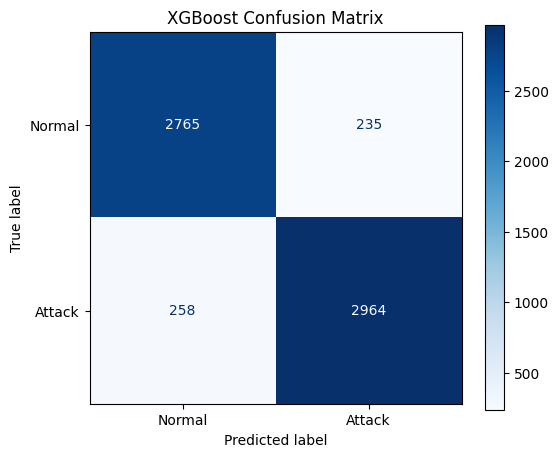

In [4]:
# ==========================================
# 5. FINAL EVALUATION
# ==========================================
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

print(f"Eval on Test set ({len(X_test)} samples)...")

# Latency Benchmark
t0 = time.perf_counter()
y_pred = best_xgb.predict(X_test)
dt = time.perf_counter() - t0

latency_ms = (dt / len(X_test)) * 1000  # often more readable in ms

print(f"\n[BENCHMARK] Total: {dt:.4f}s | Latency: {latency_ms:.4f} ms/sample")

# Metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall (Critical)": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

print("\n--- Results ---")
for k, v in metrics.items():
    print(f"{k:<20} : {v:.4f}")

# Viz
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d') # 'd' for integers is cleaner
plt.title("XGBoost Confusion Matrix")
plt.show()

## Conclusion

In this third part of the project, we focused on securing the **Ground Segment**, specifically the physical infrastructure (power supply, antenna motors) controlled via the **Modbus** protocol.

### Methodology
We selected the **TON_IoT (Modbus)** dataset from the `Train_Test` repository to ensure reproducibility.
* **Preprocessing:** We removed temporal metadata (`date`, `time`) to prevent the model from learning biases related to attack timestamps.
* **Model Selection:** Moving beyond simple baselines, we implemented **XGBoost** (Extreme Gradient Boosting), which is currently considered state-of-the-art for this type of tabular sensor data.
* **Optimization:** We used **GridSearchCV** to tune hyperparameters, resulting in an optimal configuration with `n_estimators=200`, `max_depth=7`, and `learning_rate=0.2`.

### Results Analysis
The performance on the unseen test set is highly promising for a critical intrusion detection system:

* **Recall (Sensitivity): ~92% (0.9199)**.
    * This is our critical metric. It means the model successfully detects **92% of injection attacks**. Out of 3,222 actual attacks in the test set, it correctly identified 2,964 of them.
* **Precision: ~92.6%**.
    * The false alarm rate is low (only 235 false positives out of 6,000+ samples), which prevents operator fatigue.
* **Efficiency (Inference Speed):**
    * The model demonstrates extremely low latency: approx. **16 microseconds (0.000016s) per sample**.
    * This incredible speed confirms that the model is **compatible with real-time SCADA constraints**. It can process over 60,000 requests per second, ensuring that malicious Modbus commands are blocked instantly before reaching physical actuators.

### Summary for the Global Architecture
This **"Industrial Specialist"** model is now validated. With its high Recall and microsecond-level latency, it effectively protects the Operational Technology (OT) layer.

It is ready to be integrated into our "Control Room" architecture, alongside the **Satellite Specialist** (VotingClassifier on OPSSAT) and the upcoming **Network Specialist** (based on CIC-IDS).

###  Model Export for Deployment
The XGBoost model demonstrated high accuracy on Modbus injection attacks. We now export the model object to be used by the central security monitor. Since XGBoost is sensitive to feature scaling, we also export the scaler used during preprocessing.

In [5]:
import os

print("--- EXPORTING TRAINED MODEL ---")

output_path = 'model_industrial.json'

if 'gs' in globals():
    gs.best_estimator_.save_model(output_path)

    # Quick sanity check
    if os.path.exists(output_path):
        f_size = os.path.getsize(output_path) / 1024 # KB
        print(f"Model successfully dumped to: {output_path} ({f_size:.2f} KB)")
    else:
        print(f"Error: File {output_path} not written.")

else:
    print("Error: Variable 'gs' not found. Did you run the GridSearch cell?")

--- EXPORTING TRAINED MODEL ---
Model successfully dumped to: model_industrial.json (1598.11 KB)
